In [1]:
import string
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [18]:
def head(dictionary, n):
    return dict(list(dictionary.items())[:n])

In [2]:
url = "https://github.com/bozercavdar/kickstarter-project/releases/download/v1.0/kickstarter_data_OSF.csv"
local_path = "dataset.csv"

df = pd.read_csv(local_path)

# print(df.head())

In [3]:
selected_df = df[['uid', 'blurb', 'goal', 'state', 'usd_pledged', 'category']]
selected_df['success'] = selected_df['state'] == 'successful'
selected_df.head()

/tmp/ipykernel_27940/949761106.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['success'] = selected_df['state'] == 'successful'


,uid,blurb,goal,state,usd_pledged,category,success
0,1,This project is designed to help protect the e...,2500.0,failed,0.0,Music,False
1,2,Help us built a sustainable studio & eliminate...,25000.0,failed,1.0,Technology,False
2,3,"""If I paint something, I don't want to have to...",5000.0,failed,5.0,Art,False
3,4,Our free app will allow you pool reservations ...,12000.0,failed,0.0,Food,False
4,5,Prohibition themed Gastro Pub and After Dark S...,20000.0,failed,0.0,Food,False


In [4]:
print(f"Succesful rate: {(selected_df['state']=='successful').mean()}")
print(f"Median goal: {selected_df['goal'].median()}")
print(f"# of category: {selected_df['category'].nunique()}")
print(f"Frequency: \n {selected_df['category'].value_counts()}")


Succesful rate: 0.5849306592836563
Median goal: 5000.0
# of category: 16
Frequency: 
 category
Music           22630
Film & Video    20756
Technology      16990
Publishing      16633
Art             16557
Food            12088
Games            9429
Fashion          8465
web              6088
Comics           5982
Design           5607
Photography      5314
Crafts           4591
Theater          4295
Journalism       3033
Dance            1549
Name: count, dtype: int64


In [5]:
selected_df.groupby("category")['success'].mean()

category
Art             0.574983
Comics          0.873621
Crafts          0.282945
Dance           0.601033
Design          0.591225
Fashion         0.623036
Film & Video    0.617990
Food            0.297981
Games           0.656485
Journalism      0.233103
Music           0.678878
Photography     0.364509
Publishing      0.707509
Technology      0.415539
Theater         0.615134
web             0.974376
Name: success, dtype: float64

In [6]:
adf = selected_df.head()

In [7]:
selected_df['word_count'] = selected_df['blurb'].apply(lambda blurb: len(blurb.split(" ")))

/tmp/ipykernel_27940/2075815519.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_df['word_count'] = selected_df['blurb'].apply(lambda blurb: len(blurb.split(" ")))


In [8]:
print(f"Average word number: {selected_df['word_count'].mean()}")

Average word number: 18.916966132731694


In [9]:
def count_word(text:str, word_counter:dict):
    clear_text = text.translate(str.maketrans("", "", string.punctuation)).lower()
    clear_text = " ".join(clear_text.split())
    # print(clear_text)
    for word in clear_text.split(" "):
        count = word_counter.get(word)
        if count is None:
            word_counter[word] = 1
        else:
            word_counter[word] = count + 1


In [19]:
total_word_dict = {}
for blurb in selected_df['blurb']:
    count_word(blurb, total_word_dict)

total_word_dict = dict(sorted(total_word_dict.items(), key=lambda item: item[1], reverse=True))
head(total_word_dict, 10)

{'the': 118112,
 'a': 116379,
 'and': 98671,
 'to': 90334,
 'of': 78257,
 'in': 45329,
 'for': 37171,
 'is': 36015,
 'with': 31088,
 'an': 20469}

In [20]:
stop_words = ENGLISH_STOP_WORDS

filtered_word_dict = {w: c for w, c in total_word_dict.items() if w not in stop_words}
filtered_word_dict = dict(sorted(filtered_word_dict.items(), key=lambda item: item[1], reverse=True))
head(filtered_word_dict, 10)


{'help': 16516,
 'new': 15445,
 'book': 9186,
 'music': 8920,
 'album': 8272,
 'art': 8181,
 'world': 7921,
 'make': 7390,
 'film': 6807,
 'life': 6374}

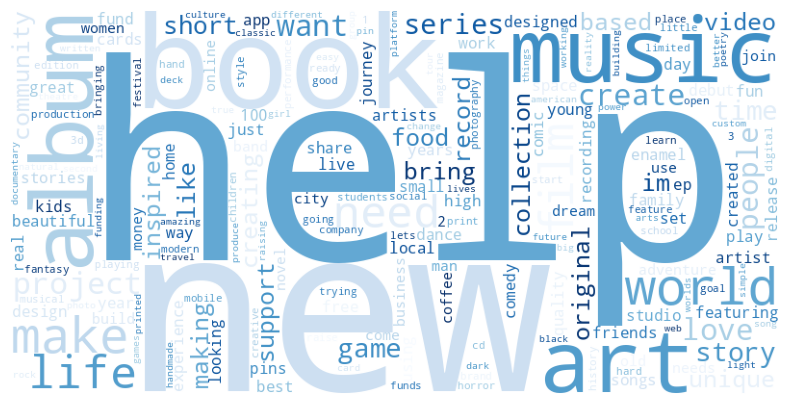

In [21]:
wordcloud = WordCloud(width=800, height=400, colormap="Blues", background_color="white").generate_from_frequencies(filtered_word_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

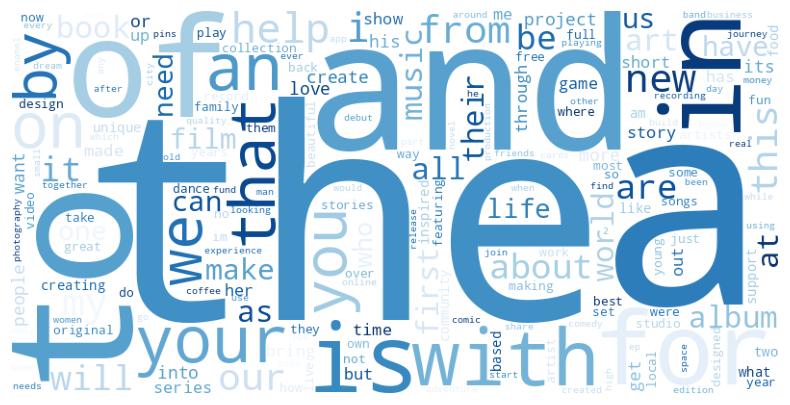

In [22]:
wordcloud = WordCloud(width=800, height=400, colormap="Blues", background_color="white").generate_from_frequencies(total_word_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [24]:
succesful_word_dict = {}
for i, row in selected_df.iterrows():
    # print(row)
    if row['success']:
        count_word(row['blurb'], succesful_word_dict)

successful_filtered_word_dict = {w: c for w, c in succesful_word_dict.items() if w not in stop_words}
successful_filtered_word_dict = dict(sorted(successful_filtered_word_dict.items(), key=lambda item: item[1], reverse=True))
head(successful_filtered_word_dict, 10)

{'new': 10252,
 'help': 10036,
 'book': 6655,
 'album': 6151,
 'music': 4933,
 'art': 4888,
 'world': 4436,
 'film': 4368,
 'make': 3785,
 'life': 3672}

In [26]:
failed_word_dict = {}
for i, row in selected_df.iterrows():
    # print(row)
    if not row['success']:
        count_word(row['blurb'], failed_word_dict)

failed_filtered_word_dict = {w: c for w, c in failed_word_dict.items() if w not in stop_words}
failed_filtered_word_dict = dict(sorted(failed_filtered_word_dict.items(), key=lambda item: item[1], reverse=True))
head(failed_filtered_word_dict, 10)

{'help': 6480,
 'new': 5193,
 'music': 3987,
 'make': 3605,
 'want': 3509,
 'world': 3485,
 'art': 3293,
 'create': 3186,
 'people': 3036,
 'need': 2794}

In [27]:
head(successful_filtered_word_dict, 20)

{'new': 10252,
 'help': 10036,
 'book': 6655,
 'album': 6151,
 'music': 4933,
 'art': 4888,
 'world': 4436,
 'film': 4368,
 'make': 3785,
 'life': 3672,
 'series': 3307,
 'need': 3299,
 'story': 3239,
 'love': 3235,
 'project': 3069,
 'short': 2745,
 'time': 2612,
 'game': 2490,
 'inspired': 2485,
 'featuring': 2402}

In [29]:
head(failed_filtered_word_dict, 20)

{'help': 6480,
 'new': 5193,
 'music': 3987,
 'make': 3605,
 'want': 3509,
 'world': 3485,
 'art': 3293,
 'create': 3186,
 'people': 3036,
 'need': 2794,
 'project': 2755,
 'life': 2702,
 'book': 2531,
 'film': 2439,
 'food': 2403,
 'love': 2379,
 'album': 2121,
 'creating': 2114,
 'like': 2013,
 'game': 1958}